# Wasserstein Barycenters in 1D

Given distributions $(\mu_i)$ and weights $(\lambda_i)$, a Wasserstein barycenter minimizes
$$
\nu^\star = \arg\min_\nu \sum_i \lambda_i W_2^2(\nu,\mu_i).
$$
In one dimension, this has a simple quantile formula:
$$
Q_{\nu^\star}(t) = \sum_i \lambda_i Q_{\mu_i}(t).
$$
This notebook illustrates barycenter shape interpolation in 1D.

A Wasserstein barycenter minimizes $\sum_k\lambda_k W_2^2(\mu,\mu_k)$. In one dimension, quantile functions linearize this geometry, so the barycenter quantile is a weighted average of input quantiles. Weight sweeps reveal displacement interpolation rather than pointwise density blending.


## Environment

We import numerical and plotting libraries and define a robust output directory for figures.


In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.grid"] = True

OUTPUT_DIR = Path("python/wasserstein-barycenters") if Path("python/wasserstein-barycenters").exists() else Path(".")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


## Build three source densities and their CDF/quantile maps

We discretize PDFs, accumulate CDFs, and invert them numerically.


In [2]:
n = 900
x = np.linspace(-4, 4, n)
dx = x[1] - x[0]

def normalize_pdf(p):
    p = np.maximum(p, 1e-14)
    return p / (p.sum() * dx)

p1 = normalize_pdf(np.exp(-0.5*((x+1.8)/0.55)**2))
p2 = normalize_pdf(np.exp(-0.5*((x-0.2)/0.9)**2))
p3 = normalize_pdf(0.6*np.exp(-0.5*((x-1.6)/0.45)**2) + 0.4*np.exp(-0.5*((x+0.5)/0.35)**2))

def cdf_from_pdf(p):
    c = np.cumsum(p) * dx
    c[-1] = 1.0
    return c

def quantile_from_cdf(c, x, t):
    return np.interp(t, c, x)

t = np.linspace(0, 1, n)
q1 = quantile_from_cdf(cdf_from_pdf(p1), x, t)
q2 = quantile_from_cdf(cdf_from_pdf(p2), x, t)
q3 = quantile_from_cdf(cdf_from_pdf(p3), x, t)


## Barycenter interpolation

For weights $\lambda=(\lambda_1,\lambda_2,\lambda_3)$, compute
$$
Q_\lambda(t)=\lambda_1 Q_1(t)+\lambda_2 Q_2(t)+\lambda_3 Q_3(t),
$$
then recover density from the pushed-forward quantile samples.


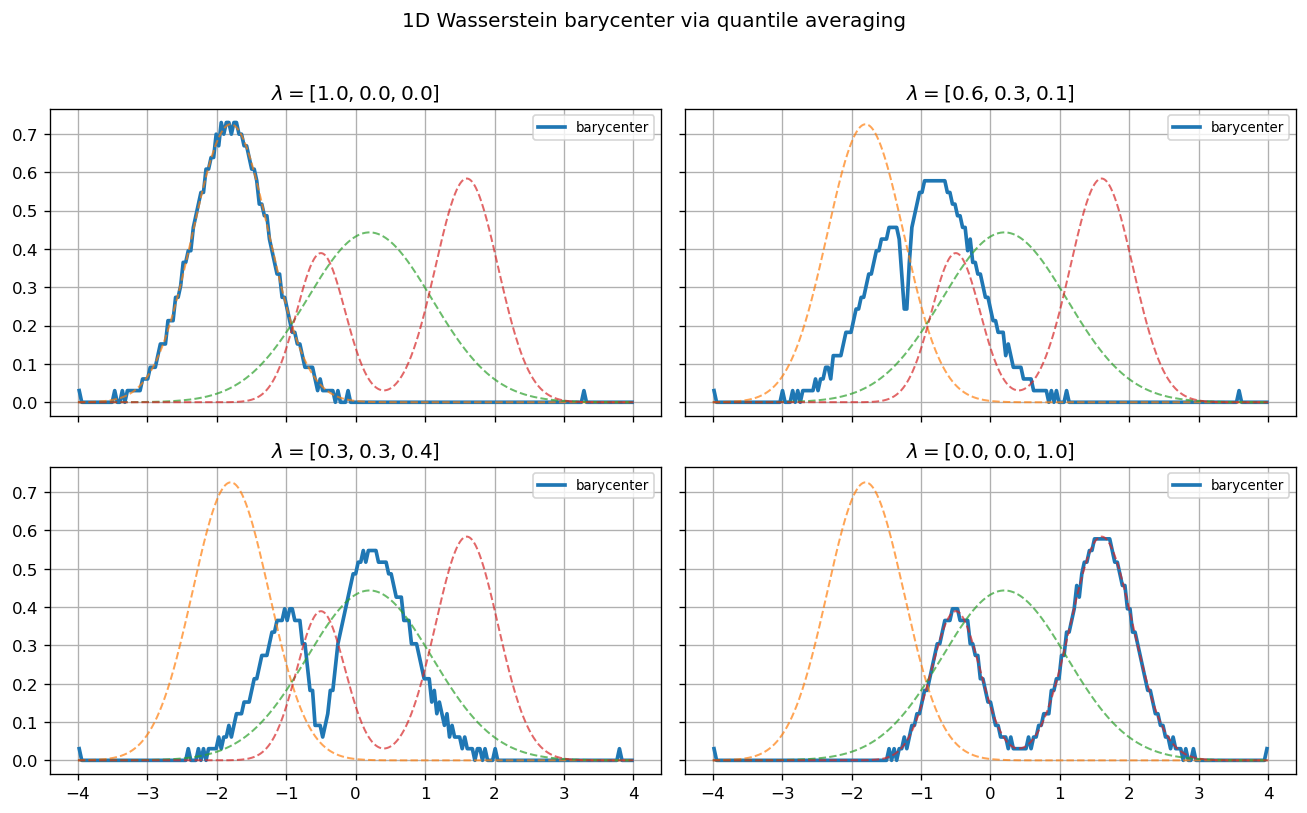

In [3]:
weights_list = [
    np.array([1.0, 0.0, 0.0]),
    np.array([0.6, 0.3, 0.1]),
    np.array([0.3, 0.3, 0.4]),
    np.array([0.0, 0.0, 1.0]),
]

fig, axes = plt.subplots(2, 2, figsize=(11, 6.6), sharex=True, sharey=True)
bins = np.linspace(-4, 4, 220)

for ax, w in zip(axes.ravel(), weights_list):
    qb = w[0]*q1 + w[1]*q2 + w[2]*q3
    hist, edges = np.histogram(qb, bins=bins, density=True)
    xc = 0.5*(edges[:-1]+edges[1:])
    ax.plot(xc, hist, lw=2.2, label="barycenter")
    ax.plot(x, p1, "--", lw=1.2, alpha=0.7)
    ax.plot(x, p2, "--", lw=1.2, alpha=0.7)
    ax.plot(x, p3, "--", lw=1.2, alpha=0.7)
    ax.set_title(fr"$\lambda={w.tolist()}$")
    ax.legend(fontsize=8)

fig.suptitle("1D Wasserstein barycenter via quantile averaging", y=1.02)
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "snippet.png", bbox_inches="tight")
plt.show()


## Bibliographical Resources

- M. Agueh, G. Carlier, "Barycenters in the Wasserstein Space", SIAM J. Math. Anal., 2011.
- M. Cuturi, A. Doucet, "Fast Computation of Wasserstein Barycenters", ICML, 2014.
- G. Peyré, M. Cuturi, *Computational Optimal Transport*, 2019.
